# DL075 宽网络核视角与特征学习

发行075映射原大纲T3。本Notebook从空内核实际重做完整实验。先预测结果，再逐单元执行；所有数据原创、CPU离线。图由固定outputs绘制，下面先核对重跑数组再展示。

In [1]:
from pathlib import Path  # 当前目录应为本单元。
import json, numpy as np  # 结果读取与数值核验。
from IPython.display import display, Image  # 内嵌PNG到Notebook。
print('working directory:', Path.cwd().name)  # 只显示目录名，避免机器路径。

working directory: 075


## 1 先做手算可核验的机制
数组形状与定义见data/README.md。不要把程序输出当作理解推导的替代。

In [2]:
from generate_data import generate  # 原创固定训练点。
from experiment import initialize, forward_jacobian  # 手写网络与Jacobian。
d = generate()  # 数据无需下载。
theta0 = initialize(8, 11)  # 24个参数。
f0, j0, h0 = forward_jacobian(theta0, d['x'])  # 输出、偏导、表示。
k0 = j0 @ j0.T  # 对称半正定Gram。
print('f, J, H, K shapes:', f0.shape, j0.shape, h0.shape, k0.shape)  # 检查每个维度。

f, J, H, K shapes: (24,) (24, 24) (24, 8) (24, 24)


In [3]:
eta = .3 / np.linalg.eigvalsh(k0/len(d['y']))[-1]  # 固定核安全谱尺度。
delta = -eta * j0.T @ (f0-d['y']) / len(d['y'])  # 首次更新。
f_real, _, _ = forward_jacobian(theta0+delta, d['x'])  # 真网络含高阶项。
f_lin = f0 + j0 @ delta  # 局部模型的一步精确值。
np.testing.assert_allclose(f_lin, f0-eta*k0@(f0-d['y'])/len(d['y']), atol=1e-12)
print('one-step prediction RMSE:', np.sqrt(np.mean((f_real-f_lin)**2)))  # 不假设为0。

one-step prediction RMSE: 0.0007795478628049876


## 2 完整实验重跑
调用run确实重新计算全部预定配置；输出另存notebook_outputs。运行时间只反映当前CPU，不构成跨机器性能比较。

In [4]:
from experiment import run  # 与命令行相同完整入口。
result = run('notebook_outputs')  # 真实重新抽样或训练，不复用固定输出。
print('unit:', result['unit'], 'runtime:', result['runtime'])  # 保存真实版本与时间。

unit: 075 runtime: {'python': '3.12.14', 'numpy': '2.3.5', 'seconds': 0.6539790669999093, 'device': 'CPU', 'dtype': 'float64'}


In [5]:
for amplitude in [.2, 1., 4.]:  # 全部幅度，不挑最佳。
    for width in [8, 32, 128]:  # 全部宽度。
        rows = [r for r in result['rows'] if r['width']==width and r['amplitude']==amplitude]
        print(amplitude, width, np.mean([r['relative_prediction_rmse'] for r in rows]))  # 三种子均值。

0.2 8 0.09410126658775063
0.2 32 0.027206219814235516
0.2 128 0.010612065886844371
1.0 8 0.1521523049852026
1.0 32 0.0991240602681727
1.0 128 0.0442769042667945
4.0 8 0.2121420079699815
4.0 32 0.15931724800606503
4.0 128 0.10943953320559573


## 3 逐数组核对固定发行结果
同环境重跑应相同；跨BLAS或平台可能有舍入差，使用小容差。NaN仅在有明确定义的未定义量处按相同位置匹配。

In [6]:
reference = np.load('outputs/trajectories.npz', allow_pickle=False)  # 固定发行证据。
replayed = np.load('notebook_outputs/trajectories.npz', allow_pickle=False)  # 刚重跑结果。
if set(reference.files) != set(replayed.files):  # 不依赖可被-O删掉的assert。
    raise ValueError('array keys differ')
for name in reference.files:  # 每个数组都检查，不只检查摘要。
    np.testing.assert_allclose(replayed[name], reference[name], rtol=1e-10, atol=1e-11, equal_nan=True)
print('checked arrays:', len(reference.files))  # 实际核验数量。

checked arrays: 193


## 4 读图并写出限制
图是make_figures.py由固定outputs产生；上一单元已核对刚重跑的全部数组。改变实验后应重新画图，不能继续把旧图当新结果。

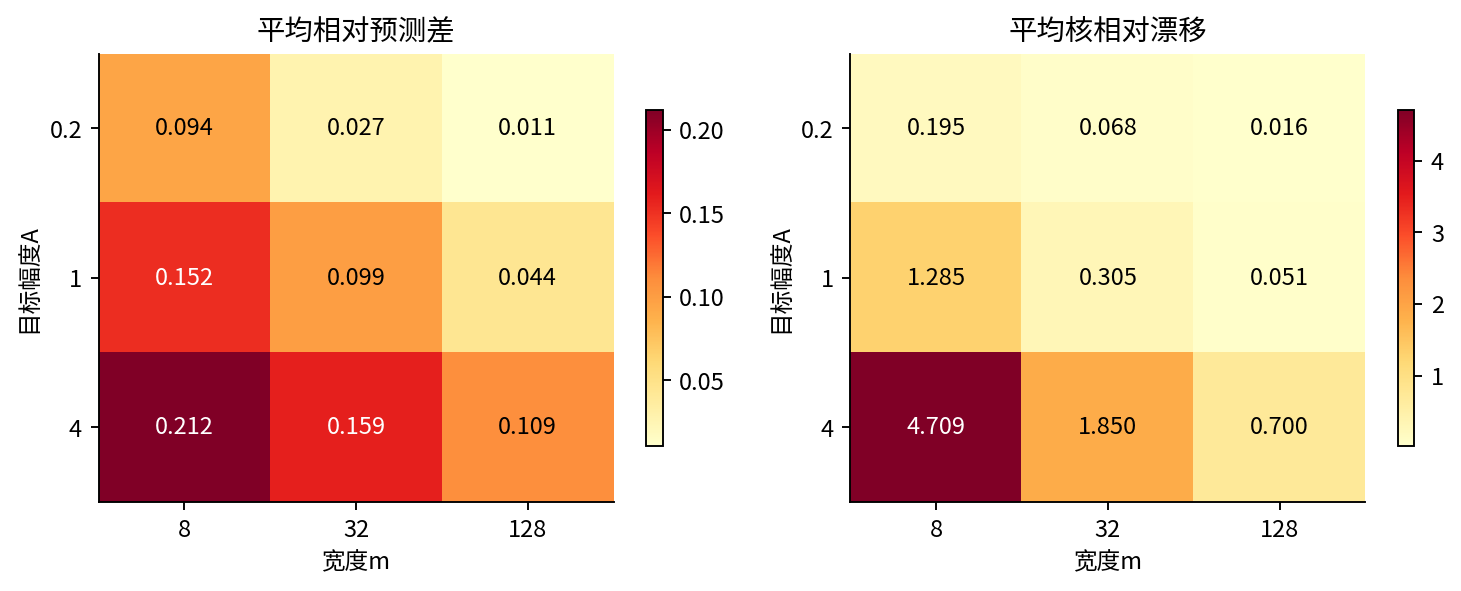

In [7]:
display(Image(filename='figures/04_scan.png'))  # 内嵌真实结果图。

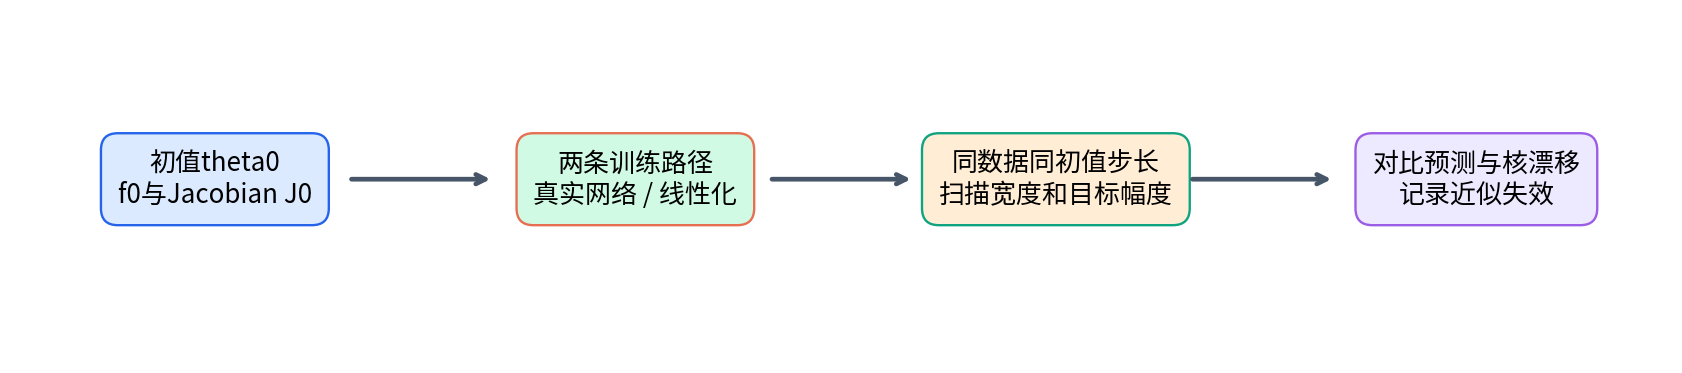

In [8]:
display(Image(filename='figures/01_comparison.png'))  # 机制图不是额外实验结果。

## 5 自检
回到lab完成故障注入与扩展设计。明确已执行和仅提出的实验，解释至少一条不能外推的条件。答案在answers.md，不使用测试结果挑选最好配置。